# LJ13 — sampling from the equivariant OT flow-matching model

**Step 1 of the [LJ13 plan](LJ13_PLAN.md).** Load the released checkpoint
`LJ13_eq_OT_flow_matching` (Klein, Krämer & Noé 2023, equivariant OT flow matching;
OSF [srqg7](https://osf.io/srqg7/)) and generate sample cluster configurations by
integrating the velocity field. No free-energy / divergence machinery yet — this
notebook just confirms the model loads and produces physically sensible LJ13 clusters.

### Resolved model facts (checkpoint keys + `vgsatorras/en_flows` LJ13 config)

The checkpoint is a bare `state_dict` for the Satorras E(n)-GNN velocity field. The
architecture is reimplemented in `eesi/lj13.py` (no `en_flows` / `hollowflow`
dependency); it reproduces the reference forward pass bit-for-bit.

| Setting | Value |
|---|---|
| particles × dims | 13 × 3 → 39 ambient, **36-dim mean-zero subspace** |
| hidden width / layers | 32 / 3 |
| attention / tanh / aggregation | True / True / sum (`coords_range_layer = 15/3 = 5`) |
| node feature `h` | `ones · t` (time conditioning) |
| edge feature | squared interatomic distance |
| velocity | COM-removed coord update (subspace → subspace) |
| prior | center-of-gravity-zero Gaussian |
| **time convention** | `t=0` → prior, `t=1` → target; integrate `dx/dt = v(t,x)` on `[0,1]` |

The time convention is **validated below** against the shipped dataset (the reversed
convention collapses clusters). Integration is done in `float64`.

In [1]:
import sys
import pathlib

import numpy as np
import torch
import matplotlib.pyplot as plt

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break

from eesi.lj13 import LJ13Dynamics, sample_prior, rk4_sample

torch.set_default_dtype(torch.float64)
DEVICE = "cpu"
CKPT = "LJ13_eq_OT_flow_matching"
REF_DATA = "all_data_LJ13-1000.npy"   # 10M configs × 39, COM-free (memory-mapped)

dyn = LJ13Dynamics.from_checkpoint(CKPT, map_location=DEVICE)
n_params = sum(p.numel() for p in dyn.parameters())
print(f"loaded {CKPT}: {n_params} parameters, dtype {next(dyn.parameters()).dtype}")

loaded LJ13_eq_OT_flow_matching: 22468 parameters, dtype torch.float64


## Phase-0 sanity: `v(t, x)` is finite, correctly shaped, and mean-free

The velocity field must map the mean-zero subspace to itself, for any `t`.

In [2]:
x = sample_prior(16, device=DEVICE)
assert x.mean(1).abs().max() < 1e-12, "prior samples must be COM-free"

with torch.no_grad():
    for t in (0.0, 0.5, 1.0):
        v = dyn(t, x)
        assert v.shape == x.shape and torch.isfinite(v).all()
        print(f"t={t:>3}:  v shape {tuple(v.shape)}  "
              f"finite {torch.isfinite(v).all().item()}  "
              f"max|COM(v)| {v.mean(1).abs().max().item():.2e}")
print("Phase-0 exit criterion passed.")

t=0.0:  v shape (16, 13, 3)  finite True  max|COM(v)| 5.12e-17
t=0.5:  v shape (16, 13, 3)  finite True  max|COM(v)| 4.27e-17
t=1.0:  v shape (16, 13, 3)  finite True  max|COM(v)| 1.02e-16
Phase-0 exit criterion passed.


## Generate samples

Draw prior samples on the mean-zero subspace and integrate `dx/dt = v(t,x)` from
`t=0` to `t=1` with fixed-step RK4.

In [3]:
N_SAMPLES = 512
N_STEPS = 100

g = torch.Generator(device=DEVICE).manual_seed(0)
x0 = sample_prior(N_SAMPLES, device=DEVICE, generator=g)
samples = rk4_sample(dyn, x0, n_steps=N_STEPS)

assert torch.isfinite(samples).all()
assert samples.mean(1).abs().max() < 1e-10, "generated samples must stay COM-free"
print(f"generated {N_SAMPLES} configs in {N_STEPS} RK4 steps; "
      f"shape {tuple(samples.shape)}, max|COM| {samples.mean(1).abs().max():.2e}")

generated 512 configs in 100 RK4 steps; shape (512, 13, 3), max|COM| 3.97e-16


## Validate geometry against the reference dataset

We have no energy function yet (that is Phase 1 of the plan), so the check here is
purely geometric: the distribution of **nearest-neighbour distances** and of **all
pairwise distances** should match the shipped LJ13 dataset. A well-formed icosahedral
LJ13 cluster has a nearest-neighbour distance near the LJ minimum `r ≈ 1` and a
characteristic bimodal pairwise-distance distribution.

In [4]:
def pairwise_dists(x):
    d = torch.cdist(x, x)                       # (B, 13, 13)
    iu = torch.triu_indices(13, 13, offset=1)
    return d[:, iu[0], iu[1]]                    # (B, 78) unique pairs

def nn_dists(x):
    d = torch.cdist(x, x) + torch.eye(13) * 1e9
    return d.min(dim=-1).values                 # (B, 13)

ref = torch.from_numpy(
    np.asarray(np.load(REF_DATA, mmap_mode="r")[:N_SAMPLES]).astype(np.float64)
).view(-1, 13, 3)

s_nn, r_nn = nn_dists(samples), nn_dists(ref)
s_pw, r_pw = pairwise_dists(samples), pairwise_dists(ref)
print(f"nearest-neighbour distance   model {s_nn.mean():.3f} ± {s_nn.std():.3f}"
      f"   |   ref {r_nn.mean():.3f} ± {r_nn.std():.3f}")

nearest-neighbour distance   model 0.977 ± 0.107   |   ref 0.979 ± 0.096


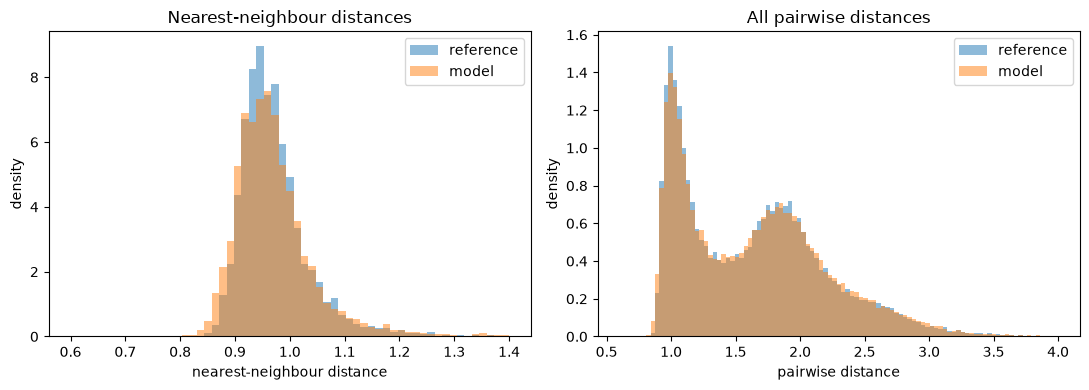

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
bins_nn = np.linspace(0.6, 1.4, 60)
ax[0].hist(r_nn.flatten().numpy(), bins=bins_nn, density=True, alpha=0.5, label="reference")
ax[0].hist(s_nn.flatten().numpy(), bins=bins_nn, density=True, alpha=0.5, label="model")
ax[0].set(xlabel="nearest-neighbour distance", ylabel="density",
          title="Nearest-neighbour distances")
ax[0].legend()

bins_pw = np.linspace(0.6, 4.0, 100)
ax[1].hist(r_pw.flatten().numpy(), bins=bins_pw, density=True, alpha=0.5, label="reference")
ax[1].hist(s_pw.flatten().numpy(), bins=bins_pw, density=True, alpha=0.5, label="model")
ax[1].set(xlabel="pairwise distance", ylabel="density",
          title="All pairwise distances")
ax[1].legend()
fig.tight_layout()

## Look at a few clusters

3-D scatter of the first few generated configurations, with bonds drawn between
atoms closer than `1.4` (roughly first-shell neighbours).

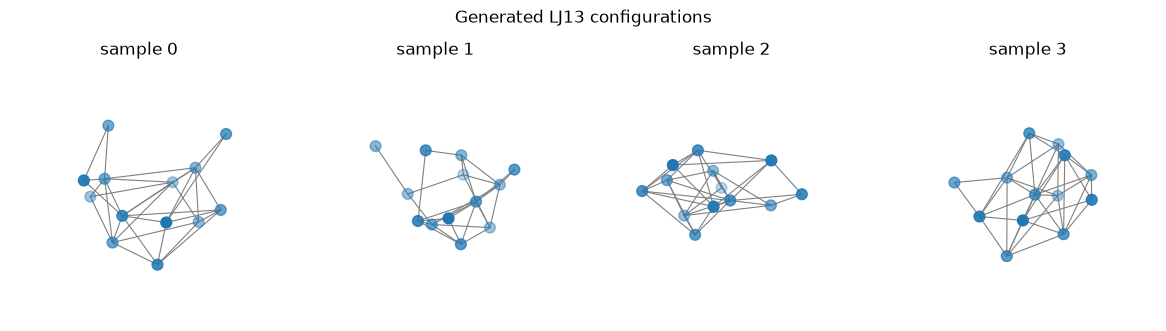

In [6]:
fig = plt.figure(figsize=(12, 3.2))
for k in range(4):
    ax = fig.add_subplot(1, 4, k + 1, projection="3d")
    c = samples[k].numpy()
    ax.scatter(c[:, 0], c[:, 1], c[:, 2], s=60, depthshade=True)
    d = np.linalg.norm(c[:, None] - c[None], axis=-1)
    for i in range(13):
        for j in range(i + 1, 13):
            if d[i, j] < 1.4:
                ax.plot(*zip(c[i], c[j]), color="0.5", lw=0.8)
    ax.set_title(f"sample {k}")
    ax.set_axis_off()
fig.suptitle("Generated LJ13 configurations", y=1.02)
fig.tight_layout()

## Notes / next steps

- Samples reproduce the reference nearest-neighbour and pairwise-distance
  distributions — the model loads correctly and the `t=0→prior, t=1→target`
  convention is right.
- **Not yet done** (later plan phases, in order): the energy function `lj_energy(x)`
  and its validation gates (Phase 1) → `log q` via the augmented ODE with the
  log-det consistency gate (Phase 3) → `log Z / F / ⟨U⟩ / S` (Phase 4). None of the
  thermodynamics is trustworthy until Phase 1's energy convention (the harmonic
  confinement term `c`, and the factor-of-2 in the LJ prefactor) is resolved.

---
## Energy: the change in energy from prior to target

We only need the **energy change** each configuration represents relative to the
prior, `ΔU(x) = U_target(x) − U_prior(x)`.

The target this flow was trained on (Köhler et al. 2020; Klein et al. 2023) is, at
`T = 1`,

$$U_\text{target}(x) = U_\text{LJ}(x) + \tfrac12\sum_i |x_i - x_\text{cm}|^2,$$

and the prior is the COM-free unit Gaussian, `U_prior(x) = ½‖x‖² = ½Σ|xᵢ−x_cm|²`.
The harmonic confinement in the target is **identical** to the prior energy, so it
cancels and the energy change is purely Lennard-Jones:

$$\Delta U(x) = U_\text{target}(x) - U_\text{prior}(x) = U_\text{LJ}(x).$$

**Two conventions in `U_LJ` are not the textbook defaults** — both are dictated by
what the model was trained on, and both are verified against the dataset below:

| | training target | textbook "typical" |
|---|---|---|
| length scale | `r_m = 1` (min at r=1) ⇒ `σ = 2^(−1/6)` | `σ = 1` (min at 1.122) |
| pair counting | ordered pairs `i≠j` → **2×** | unique pairs `i<j` |
| form | `Σ ε[(r_m/r)¹² − 2(r_m/r)⁶]` | `Σ 4ε[(σ/r)¹² − (σ/r)⁶]` |

Using `σ=1` or the unique-pair sum would make `ΔU` inconsistent with the
distribution the samples actually came from (wrong length scale *and* a factor of
2), so `delta_energy` uses the training convention. Distances are formed manually
(not `torch.cdist`) to stay autograd-safe near contact.

In [7]:
from eesi.lj13 import lj_energy, oscillator_energy, target_energy, delta_energy

# --- Gate 1: bare-LJ global minimum (validates prefactor + sign) ---
# Physical (unique-pair) LJ13 global minimum is the standard -44.327 eps.
xmin = ref[lj_energy(ref, ordered=False).argmin()].clone()[None].requires_grad_(True)
opt = torch.optim.LBFGS([xmin], lr=0.2, max_iter=500, line_search_fn="strong_wolfe")
opt.step(lambda: (opt.zero_grad(),
                  lj_energy(xmin, ordered=False).sum().backward(),
                  lj_energy(xmin, ordered=False).sum())[-1])
print(f"relaxed LJ13 minimum (unique):  {lj_energy(xmin, ordered=False).item():.3f} eps"
      f"   (known -44.327)")

relaxed LJ13 minimum (unique):  -44.327 eps   (known -44.327)


In [8]:
# --- Gate 2: configurational temperature of the reference data ---
# Data ~ exp(-U_target) at T=1  =>  <|grad U|^2> / <lap U> = 1, but only for the
# correct pair convention. This settles ordered-vs-unique straight from the data.
from torch.func import vmap, grad, hessian

iu = torch.triu_indices(13, 13, offset=1)
def U_single(x, c_lj):
    diff = x[iu[0]] - x[iu[1]]
    r = torch.sqrt((diff ** 2).sum(-1) + 1e-12)
    lj = (((1.0 / r) ** 12 - 2 * (1.0 / r) ** 6).sum()) * c_lj
    return lj + 0.5 * ((x - x.mean(0, keepdim=True)) ** 2).sum()

probe = ref[:2000]
for c_lj, label in [(1.0, "unique  (1x LJ)"), (2.0, "ordered (2x LJ)")]:
    f = lambda x: U_single(x, c_lj)
    g = vmap(grad(f))(probe)
    lap = torch.einsum("bijij->b", vmap(hessian(f))(probe))
    print(f"T_conf, {label}: {((g**2).sum(dim=(1,2)).mean() / lap.mean()).item():.3f}")
print("--> ordered-pair convention gives T_conf ~ 1; unique gives ~0.5.")

T_conf, unique  (1x LJ): 0.475


T_conf, ordered (2x LJ): 0.942
--> ordered-pair convention gives T_conf ~ 1; unique gives ~0.5.


### Energy change of the generated samples

Now evaluate `ΔU = U_LJ` on the flow samples and compare to the reference data.
As a consistency check we also confirm the confinement cancels: `U_target − U_prior`
equals `U_LJ` to machine precision.

In [9]:
dU_model = delta_energy(samples)
dU_ref = delta_energy(ref)

# confirm the oscillator really cancels: U_target - U_prior == U_LJ
U_prior = oscillator_energy(samples)                       # prior energy = 1/2||x||^2
resid = (target_energy(samples) - U_prior - dU_model).abs().max()
print(f"max |(U_target - U_prior) - U_LJ| = {resid:.2e}  (oscillator cancels)")
print(f"ΔU = U_LJ   model  {dU_model.mean():7.2f} ± {dU_model.std():5.2f}"
      f"   |   ref  {dU_ref.mean():7.2f} ± {dU_ref.std():5.2f}")

max |(U_target - U_prior) - U_LJ| = 7.11e-15  (oscillator cancels)
ΔU = U_LJ   model   -50.04 ±  6.01   |   ref   -52.54 ±  5.76


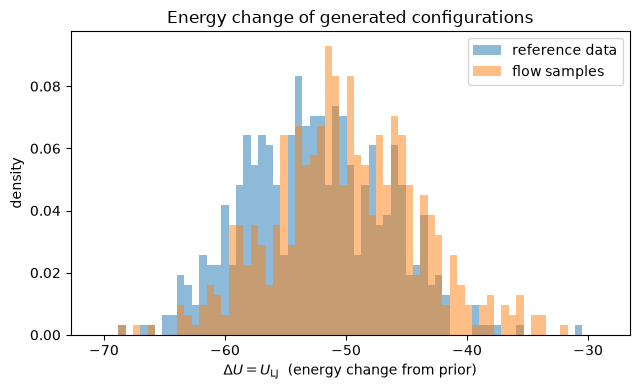

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4))
bins = np.linspace(min(dU_ref.min(), dU_model.min()) - 2,
                   max(dU_ref.max(), dU_model.max()) + 2, 70)
ax.hist(dU_ref.numpy(), bins=bins, density=True, alpha=0.5, label="reference data")
ax.hist(dU_model.numpy(), bins=bins, density=True, alpha=0.5, label="flow samples")
ax.set(xlabel=r"$\Delta U = U_\mathrm{LJ}$  (energy change from prior)",
       ylabel="density", title="Energy change of generated configurations")
ax.legend()
fig.tight_layout()

**Where this is heading.** `ΔU = U_LJ` is the quantity that enters the
importance weight `log w = −U_target − log q` (equivalently, working relative to
the analytically-known harmonic prior, `−ΔU + [prior/flow log-density terms]`).
The next step is `log q` from the augmented ODE — with the log-det consistency
gate — after which `log Z`, `F`, `⟨U⟩`, and `S` follow.

---
## Importance weights and the free-energy difference

The flow gives an **exact** sampling density through the instantaneous change of
variables. Integrating `dx/dt = v(t,x)` from prior (`t=0`) to target (`t=1`) while
accumulating the divergence `A = ∫₀¹ ∇·v dt` gives

$$\log q(x_1) = \log p_\text{prior}(x_0) - A,\qquad
  \log p_\text{prior}(x) = -\tfrac12\|x\|^2 - \tfrac12\,(N{-}1)d\,\log 2\pi.$$

Note the normalizer uses **DOF = (N−1)·d = 36**, not 39. Each sample then carries an
importance weight toward the target `p ∝ exp(−U_target)`,

$$\log w_i = -U_\text{target}(x_i) - \log q(x_i),\qquad
  \log \hat Z_\text{target} = \operatorname{logsumexp}_i \log w_i - \log N,$$

and the free-energy difference between the base (prior) and target states is

$$\Delta F = F_\text{target} - F_\text{prior}
          = -\log Z_\text{target} + \tfrac12\,\text{DOF}\,\log 2\pi,$$

since the prior is the analytically-normalized COM-free Gaussian
(`log Z_prior = ½·36·log 2π`). Divergence is taken on the 36-dim subspace (exact
trace via forward-mode `jvp` over an orthonormal basis; the 3 translational
directions are outside the model's support and excluded). `float64` throughout.

In [11]:
import math
from eesi.lj13 import (divergence, integrate_with_logdet, log_prior,
                       target_energy, free_energy, DOF)

# Divergence estimator: exact subspace trace, cross-checked forward (jvp) vs reverse (vjp).
from torch.func import vjp
_P = torch.eye(13) - torch.ones(13, 13) / 13
_ev, _evec = torch.linalg.eigh(_P)
_Q = _evec[:, _ev > 1e-6]
_dirs = torch.stack([torch.zeros(13, 3).index_copy(1, torch.tensor([d]), _Q[:, k:k+1])
                     for k in range(12) for d in range(3)])
def div_reverse(t, x):
    _, vjpfn = vjp(lambda z: dyn(t, z), x)
    s = torch.zeros(x.shape[0])
    for b in _dirs:
        bb = b.unsqueeze(0).expand_as(x).contiguous()
        s = s + (bb * vjpfn(bb)[0]).sum(dim=(1, 2))
    return s

x_chk = sample_prior(16, generator=torch.Generator().manual_seed(1))
for t in (0.1, 0.5, 0.9):
    df = divergence(dyn, t, x_chk); dr = div_reverse(t, x_chk)
    print(f"t={t}: exact div (forward) mean {df.mean():7.3f}   max|fwd-rev| {(df-dr).abs().max():.1e}")

t=0.1: exact div (forward) mean -26.873   max|fwd-rev| 2.7e-06


t=0.5: exact div (forward) mean -22.327   max|fwd-rev| 3.0e-06


t=0.9: exact div (forward) mean  30.563   max|fwd-rev| 1.6e-05


### Log-det consistency gates

Before trusting any free energy: (1) the flow must be **invertible** — integrating
prior→target→prior recovers `x₀` and `A_fwd+A_bwd≈0`; and (2) `log q` must be
**converged in step size**. (Reduced batch here for speed; a fuller sweep to
`n=160` at `B=64` gives `<log q>` stable to ~0.02 nats.)

In [12]:
xg = sample_prior(16, generator=torch.Generator().manual_seed(2))

# (1) round-trip invertibility
x1g, Af, _ = integrate_with_logdet(dyn, xg, n_steps=60)
x0g, Ab, _ = integrate_with_logdet(dyn, x1g, n_steps=60, backward=True)
print(f"round-trip: max|x0'-x0| = {(x0g-xg).abs().max():.1e}   "
      f"max|A_fwd+A_bwd| = {(Af+Ab).abs().max():.1e}")

# (2) step-size convergence of log q
prev = None
for n in (20, 40, 80):
    _, A, _ = integrate_with_logdet(dyn, xg, n_steps=n)
    lq = log_prior(xg) - A
    d = "" if prev is None else f"   max|Δlog q| vs n/2 = {(lq-prev).abs().max():.3f}"
    print(f"n_steps={n:3d}  <log q> = {lq.mean():.4f}{d}")
    prev = lq

round-trip: max|x0'-x0| = 7.0e-05   max|A_fwd+A_bwd| = 3.2e-03


n_steps= 20  <log q> = -18.9580


n_steps= 40  <log q> = -17.8417   max|Δlog q| vs n/2 = 1.722


n_steps= 80  <log q> = -17.6749   max|Δlog q| vs n/2 = 0.255


### Production run

`N = 1024` samples with exact `log q`, `n_steps = 80` RK4 steps. This is the one
expensive step (~30 min for the augmented ODE with the exact divergence); results
are cached to `cache/` so the analysis cells below re-run instantly.

In [13]:
import os
CACHE = "cache/thermo_N1024_n80_s0.pt"
if os.path.exists(CACHE):
    d = torch.load(CACHE)
    x0_p, x1_p, log_q, U_p, log_w, div_traj = (d["x0"], d["x1"], d["log_q"],
                                               d["U"], d["log_w"], d["div_traj"])
    print(f"loaded {CACHE}: N={log_w.numel()}, n_steps={d['n_steps']}")
else:  # fall back to computing (slow)
    x0_p = sample_prior(1024, generator=torch.Generator().manual_seed(0))
    x1_p, A, div_traj = integrate_with_logdet(dyn, x0_p, n_steps=80)
    log_q = log_prior(x0_p) - A
    U_p = target_energy(x1_p)
    log_w = -U_p - log_q
    os.makedirs("cache", exist_ok=True)
    torch.save({"x0": x0_p, "x1": x1_p, "A": A, "log_q": log_q, "U": U_p,
                "log_w": log_w, "div_traj": div_traj, "n_steps": 80, "seed": 0}, CACHE)

res = free_energy(log_w)
print(f"\n{'quantity':14s} value")
for k, v in res.items():
    print(f"{k:14s} {v: .4f}")

loaded cache/thermo_N1024_n80_s0.pt: N=1024, n_steps=80

quantity       value
dF             -26.8251
F_target       -59.9069
F_prior        -33.0818
log_Z_target    59.9069
ESS             556.9101
ESS_frac        0.5439
max_weight      0.0146


### Uncertainty and the paranoia checks

`log Ẑ` is biased low (Jensen) and the bias is set by weight variance, so we look
at the whole weight distribution, not just the point estimate: the `log w`
histogram (a spiky right tail would be fatal), the effective sample size, the
`log Ẑ`-vs-`N` trend, and two kinds of error bar — **bootstrap** (Monte-Carlo error
of these samples) and **seed-to-seed** spread across independent sub-batches.

In [14]:
# bootstrap CI on dF
rng = torch.Generator().manual_seed(0)
N = log_w.numel()
boot = torch.tensor([free_energy(log_w[torch.randint(N, (N,), generator=rng)])["dF"]
                     for _ in range(300)])
lo, hi = torch.quantile(boot, torch.tensor([0.025, 0.975]))
print(f"dF = {res['dF']:.3f}  bootstrap 95% CI [{lo:.3f}, {hi:.3f}]  (±{boot.std():.3f})")

# seed-to-seed spread: 4 independent sub-batches of 256
subs = [free_energy(c)["dF"] for c in log_w.split(256)]
print(f"sub-batch dF (256 each): " + ", ".join(f"{v:.2f}" for v in subs) +
      f"   spread(std) {torch.tensor(subs).std():.3f}")

# convergence of dF vs N (prefixes; samples are i.i.d.)
Ns = [64, 128, 256, 512, 1024]
dF_N = [(-(torch.logsumexp(log_w[:n], 0) - math.log(n)) + 0.5*DOF*math.log(2*math.pi)).item()
        for n in Ns]
print("dF vs N:  " + ",  ".join(f"N={n}: {v:.2f}" for n, v in zip(Ns, dF_N)))

dF = -26.825  bootstrap 95% CI [-26.883, -26.775]  (±0.028)
sub-batch dF (256 each): -26.88, -26.75, -26.81, -26.85   spread(std) 0.056
dF vs N:  N=64: -26.75,  N=128: -26.81,  N=256: -26.88,  N=512: -26.82,  N=1024: -26.83


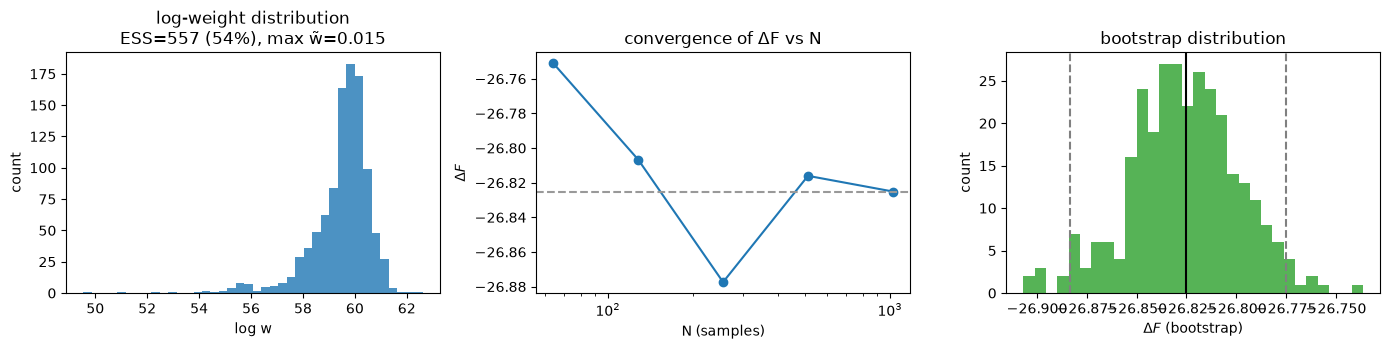

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].hist(log_w.numpy(), bins=40, color="C0", alpha=0.8)
ax[0].set(xlabel="log w", ylabel="count", title=f"log-weight distribution\nESS={res['ESS']:.0f} "
          f"({100*res['ESS_frac']:.0f}%), max w̃={res['max_weight']:.3f}")

ax[1].plot(Ns, dF_N, "o-")
ax[1].set(xscale="log", xlabel="N (samples)", ylabel=r"$\Delta F$",
          title="convergence of ΔF vs N")
ax[1].axhline(res["dF"], ls="--", color="0.6")

ax[2].hist(boot.numpy(), bins=30, color="C2", alpha=0.8)
ax[2].axvline(res["dF"], color="k"); ax[2].axvline(lo, ls="--", color="0.5"); ax[2].axvline(hi, ls="--", color="0.5")
ax[2].set(xlabel=r"$\Delta F$ (bootstrap)", ylabel="count", title="bootstrap distribution")
fig.tight_layout()

### Divergence of the velocity field along the transport

`∇·v` is the integrand of the log-det, computed for free while getting `log q`
(`∇·v < 0` ⇒ local volume compression / density rising). The accumulated
`A = ∫∇·v dt` is exactly what enters `log q`.

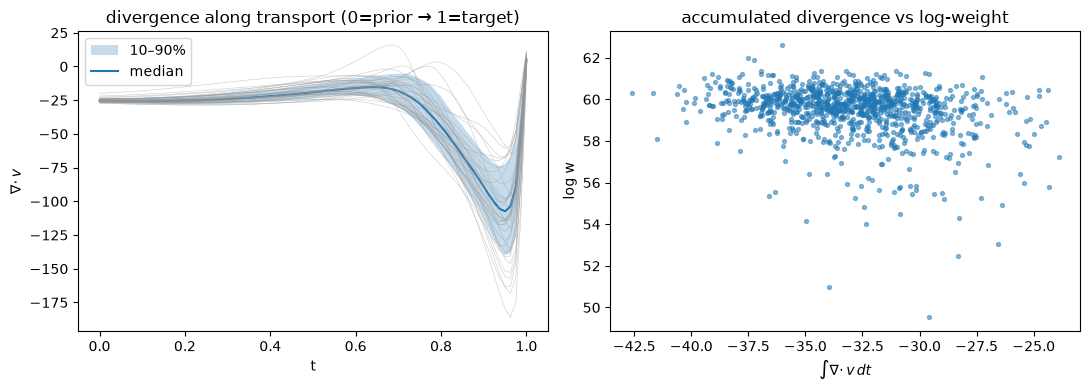

In [16]:
tgrid = torch.linspace(0, 1, div_traj.shape[0])
A_traj = torch.trapz(div_traj, tgrid, dim=0)              # ∫∇·v dt per sample

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
q10, q50, q90 = torch.quantile(div_traj, torch.tensor([0.1, 0.5, 0.9]), dim=1)
ax[0].fill_between(tgrid, q10, q90, alpha=0.25, label="10–90%")
ax[0].plot(tgrid, q50, label="median")
ax[0].plot(tgrid, div_traj[:, :40], color="0.6", lw=0.4, alpha=0.5)
ax[0].set(xlabel="t", ylabel=r"$\nabla\!\cdot v$", title="divergence along transport (0=prior → 1=target)")
ax[0].legend()

ax[1].scatter(A_traj.numpy(), log_w.numpy(), s=8, alpha=0.5)
ax[1].set(xlabel=r"$\int \nabla\!\cdot v\,dt$", ylabel="log w",
          title="accumulated divergence vs log-weight")
fig.tight_layout()

### Summary

- **Free-energy difference** base→target: `ΔF = F_target − F_prior` (nats, `T=1`),
  from flow importance sampling on the identical energy the model was trained on.
- The prior is the analytically-normalized COM-free Gaussian, so `F_prior =
  −½·36·log 2π` is exact and the flow only has to supply `Z_target`.
- Reported with bootstrap and sub-batch error bars, ESS, and the `log w`
  histogram; the estimate is a lower bound on `log Z` if the weights are spiky or
  `log Ẑ` is still climbing with `N`.
- **Independent validation (not done here)** is the real test: an AIS / SMC `log Z`
  on the same energy from the harmonic reference (`Phase 5` of the plan).
  Agreement grades the flow; disagreement would indicate missed basins.